In [1]:
from datetime import datetime
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.sorted_portfolios import get_sorted_index, get_sorted_portfolio
from src.utils import *
from src.signals import *
from src.matrix import *
from src.visualization import plot_group_cum, plot_solo_cum
from src.metrics import *

plt.style.use("default")
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

# Data Preparation

In [2]:
# CRSP data
crsp = pd.read_csv("data//csrp_msf.csv", index_col=0)
crsp['date'] = pd.to_datetime(crsp.date)
# Construct dfs
dfs = {}
# Price DataFrame (abs for negative price)
dfs['prc'] = date_cusip_pivot(crsp, 'prc_adj')
dfs['prc'][dfs['prc'] < 0] = np.nan
# Return DataFrame
dfs['ret'] = get_simple_ret(dfs['prc'])
# Volume Threshold DataFrame. 
# # If the value (i, j) is NaN, the stock(i) at time (j) is excluded in sorting.
dfs['idx_vol_threshold'] = get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.30)
# Index for June
idx_june = dfs['ret'].index.month == 6
# Index for March, June, September, and December
idx_Q = idx_june.copy()
for month in [3, 9, 12]:
    idx_Q = idx_Q | (dfs['ret'].index.month == month)

In [3]:
# Compustat quarterly data
comp_fundq = pd.read_csv("data//comp_fundq.csv", index_col=0).rename(columns={"datadate": "date"})
# Use the first eight codes to match the crsp cusip
comp_fundq['cusip'] = comp_fundq['cusip'].apply(lambda x: str(x)[:8])
comp_fundq['date'] = pd.to_datetime(comp_fundq.date)
# Drop the "nan" cusip data
comp_fundq = comp_fundq[~(comp_fundq.cusip == "nan")].reset_index(drop=True)

# Size (Quality Check)

In [4]:
# Construct the size for each stock
df_size = get_size_df(crsp, holding_period=12)
# We re-balance the portfolio in every June
df_size[~idx_june] = np.nan
df_size[idx_june].dropna(how='all').head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-06-30,-6201.0625,NaN,NaN,NaN,NaN,NaN,NaN,8628.125,-1168.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-06-30,15333.7500,NaN,NaN,NaN,NaN,NaN,NaN,14076.000,-1475.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1977-06-30,14358.5000,NaN,NaN,NaN,NaN,NaN,NaN,12792.375,-1787.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-06-30,20590.5000,NaN,NaN,NaN,NaN,NaN,NaN,17741.750,-1501.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16419.000,-2493.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Get the list of index DataFrame for size
df_size_idx_l = get_sorted_index(df_size * dfs['idx_vol_threshold'])
# The lowest group weights calculated on 1976-06-30
df_size_idx_l[0][idx_june].dropna(how='all').iloc[0, :].dropna()

cusip
00504110    1.0
00635610    1.0
00784210    1.0
00818510    1.0
01388010    1.0
           ... 
96083510    1.0
96501010    1.0
96735210    1.0
98117910    1.0
98233910    1.0
Name: 1976-06-30 00:00:00, Length: 177, dtype: float64

In [6]:
# Get the sorted size portfolio
size_portfolio = get_sorted_portfolio(df_ret=dfs['ret'], df_idx_l=df_size_idx_l)
size_portfolio.tail(5)

,0,1,2,3,4,5,6,7,8,9
date,,,,,,,,,,
2023-08-31,-0.140359,-0.140256,-0.126444,-0.111060,-0.067492,-0.061195,-0.065789,-0.031744,-0.034621,-0.028088
2023-09-29,-0.105516,-0.107871,-0.100135,-0.087787,-0.072226,-0.064684,-0.071455,-0.055925,-0.053973,-0.045034
2023-10-31,-0.166769,-0.135085,-0.125033,-0.100449,-0.093264,-0.076850,-0.067854,-0.060024,-0.064613,-0.031534
2023-11-30,0.106149,0.063351,0.060065,0.087999,0.099880,0.094608,0.112342,0.091921,0.097287,0.092623
2023-12-29,0.015897,0.160405,0.188003,0.179407,0.153302,0.129995,0.139066,0.093481,0.090802,0.059419


In [7]:
def process_ff(df):
    df = df / 100
    # Convert index
    df.index = df.index.to_series().apply(lambda x: pd.to_datetime(f"{str(x)[:4]}-{str(x)[4:]}-01") + pd.offsets.MonthEnd(0))
    return df

def ls(df, l, s, cost =0):
    return df.iloc[:, l] - df.iloc[:, s] - cost


# Fama-French SMB factor
ff_size = process_ff(pd.read_csv('data//Portfolios_Formed_on_ME.CSV', index_col=0))
# Select the sorted decile portfolios
ff_size = ff_size.iloc[:, 9:]

In [8]:
dfs['ret']

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-03-31,0.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.023810,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-05-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.414634,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,NaN,NaN,NaN,NaN,0.181989,NaN,-0.101368,0.030100,NaN,NaN,...,2.643836,NaN,-0.175652,NaN,NaN,NaN,NaN,NaN,-0.167598,NaN
2023-09-29,NaN,NaN,NaN,NaN,-0.231746,NaN,-0.098160,-0.033604,NaN,NaN,...,-0.041353,NaN,-0.089311,NaN,NaN,NaN,NaN,NaN,-0.134228,NaN
2023-10-31,NaN,NaN,NaN,NaN,-0.095041,NaN,-0.042026,-0.002856,NaN,NaN,...,NaN,NaN,-0.365251,NaN,NaN,NaN,NaN,NaN,-0.182946,NaN


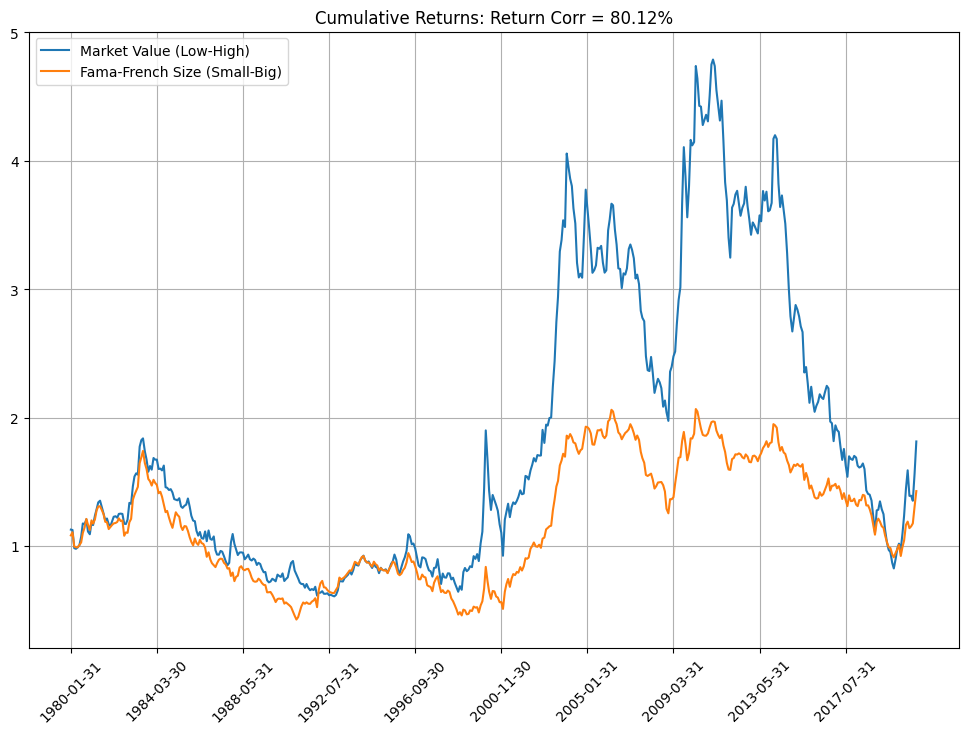

In [9]:
# Select the time to visualize
start = (1980, 1, 1)
end = (2020, 12, 31)
temp = filter_datetime_df(size_portfolio, start, end)
temp_ff = filter_datetime_df(ff_size, start, end)
# Visualization
plt.figure(figsize=(12, 8))
plt.plot(temp.index, (1+ls(temp, 0, -1)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp.index, (1+ls(temp_ff, 0, -1)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
corr = np.corrcoef([ls(temp, 0, -1), ls(temp_ff, 0, -1)])[0, 1]
plt.legend()
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.xticks(temp.index[::50], rotation=45)
plt.show()

# 3 factors

In [10]:
# Return for FF 3 factors
factor3 = pd.read_csv('data//F-F_Research_Data_Factors.CSV', index_col=0, skiprows=3, skipfooter=1, header=0)
factor3 = factor3.iloc[:1179, :]

In [11]:
factor3 = factor3.astype('float') / 100
factor3.index = pd.to_datetime(factor3.index, format='%Y%m') + pd.offsets.MonthEnd(0)
factor3

,Mkt-RF,SMB,HML,RF
1926-07-31,0.0296,-0.0256,-0.0243,0.0022
1926-08-31,0.0264,-0.0117,0.0382,0.0025
1926-09-30,0.0036,-0.0140,0.0013,0.0023
1926-10-31,-0.0324,-0.0009,0.0070,0.0032
1926-11-30,0.0253,-0.0010,-0.0051,0.0031
...,...,...,...,...
2024-05-31,0.0434,0.0078,-0.0166,0.0044
2024-06-30,0.0277,-0.0306,-0.0331,0.0041
2024-07-31,0.0124,0.0680,0.0573,0.0045
2024-08-31,0.0161,-0.0355,-0.0113,0.0048


# Price Momentum

In [12]:
# Construct price momentum
df_mom = get_momentum(dfs['ret'])
df_mom.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1976-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-05-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


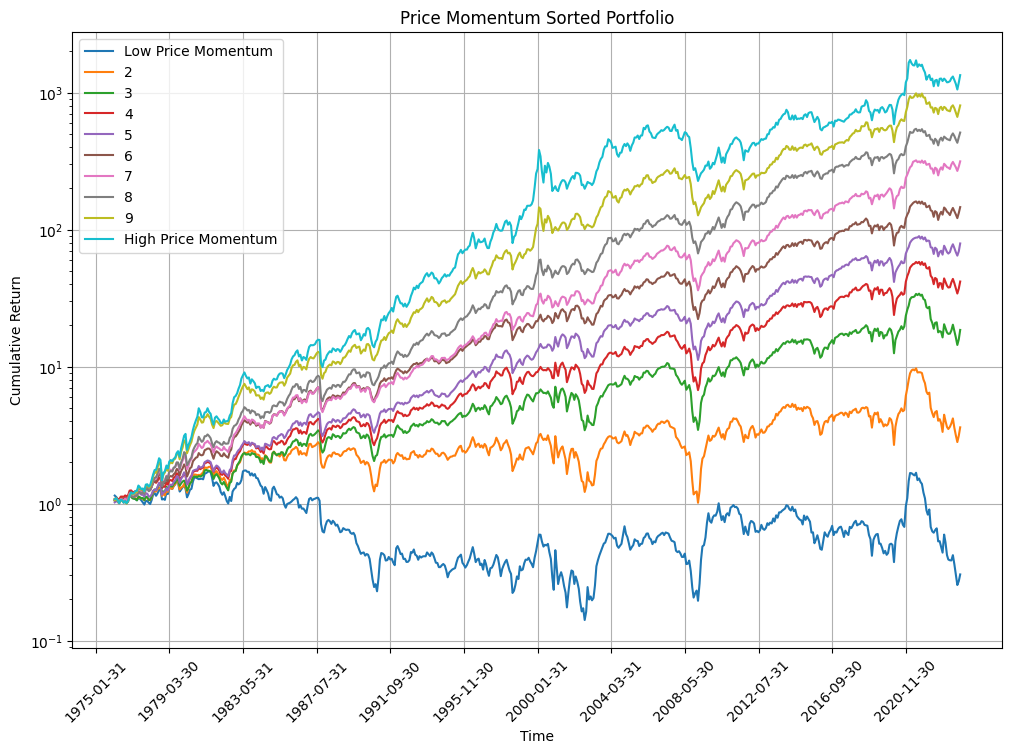

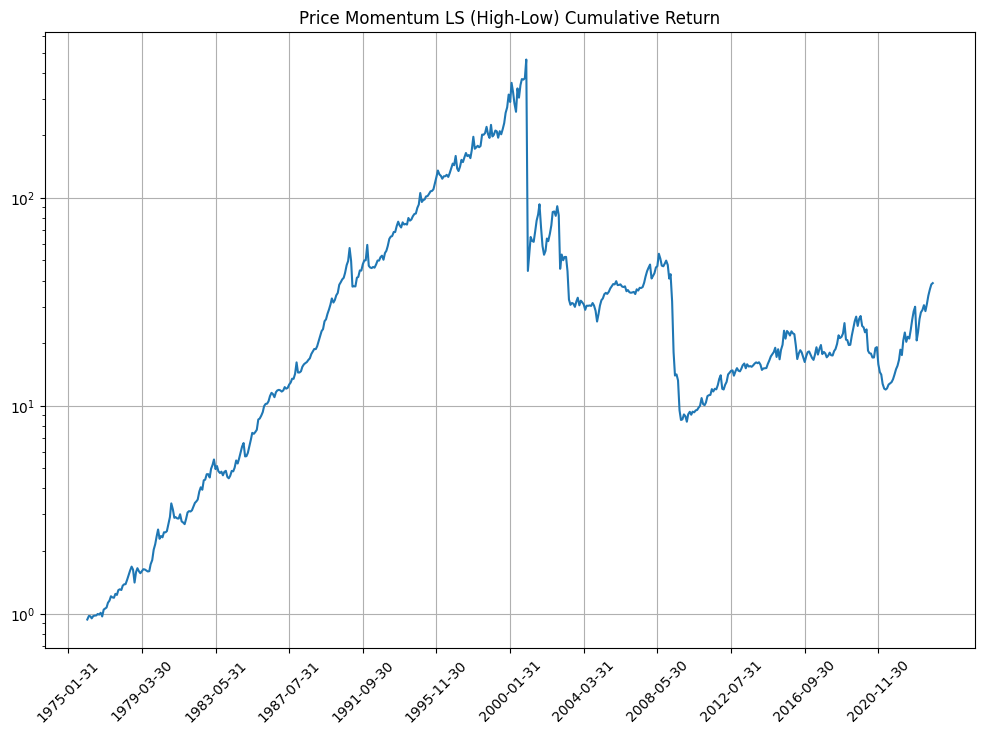

In [13]:
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(df_mom * dfs['idx_vol_threshold'], holding_period=1)
)
# Visualization
plot_group_cum(mom_portfolio, "Price Momentum")
plot_solo_cum(ls(mom_portfolio, -1, 0), "Price Momentum LS (High-Low) Cumulative Return")

# EPS

In [14]:
# Construct earnings per share (EPS)
df_eps = get_eps_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_eps[~idx_Q] = np.nan
df_eps.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.08,NaN,NaN,NaN,NaN,NaN,NaN,0.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


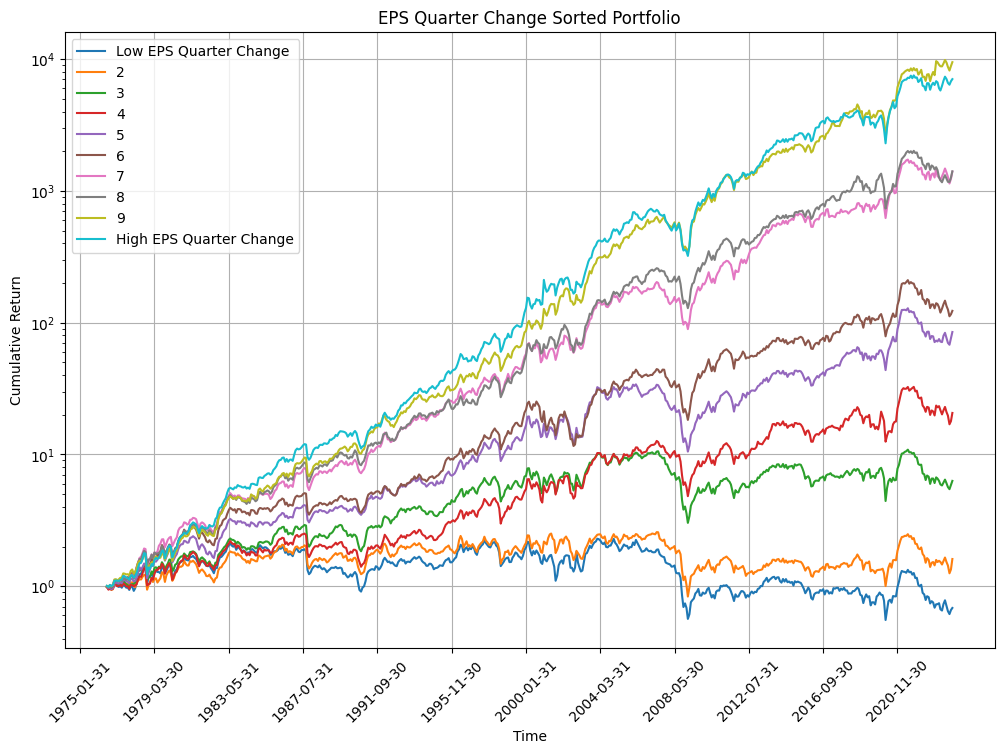

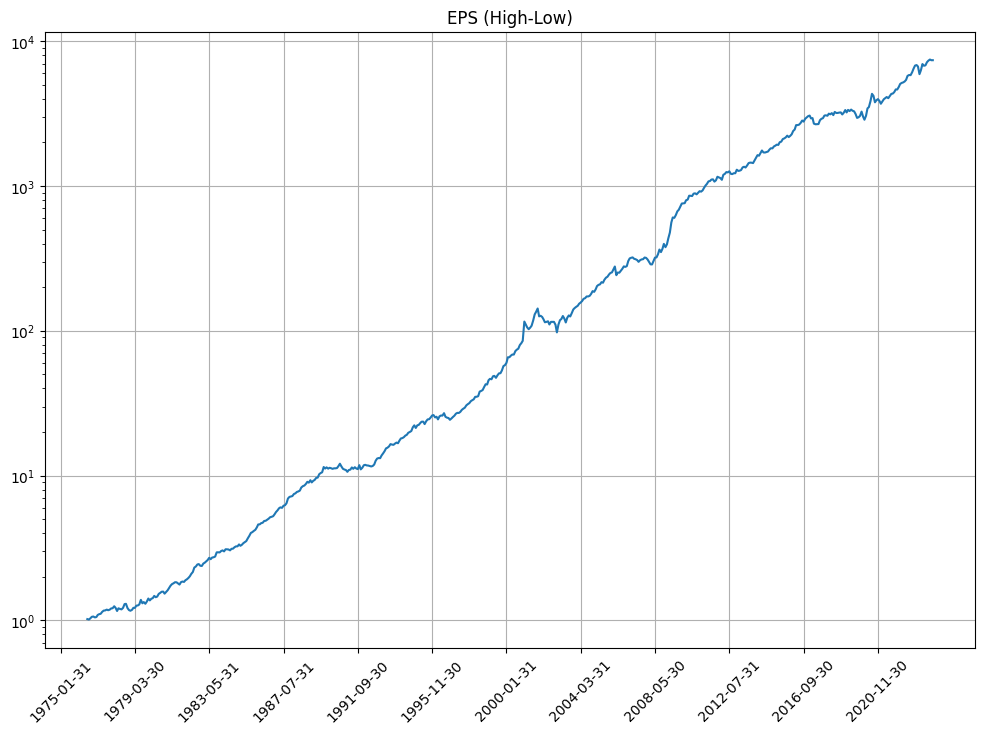

In [15]:
# Get the year over year change
df_eps_pct = df_eps.diff(3) / df_eps.rolling(window=36, min_periods=6).std()
# Compute the portfolio
eps_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(df_eps_pct * dfs['idx_vol_threshold'],holding_period=3)
)
# Visualization
plot_group_cum(eps_pct_portfolio, "EPS Quarter Change")
plot_solo_cum(ls(eps_pct_portfolio, -1, 0), "EPS (High-Low)")

# PM

In [16]:
# Construct the profit margin (PM)
df_pm = get_pm_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_pm[~idx_Q] = np.nan
df_pm.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.016822,NaN,NaN,NaN,NaN,NaN,NaN,0.014063,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.060591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.046715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.049132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.044743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Construct the profit margin quarterly change
df_pm_pct =  df_pm.diff(3) / df_pm.rolling(window=36, min_periods=6).std()
# Construct the PM momentum portfolio
pm_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
)

In [18]:
# Construct the profit margin (PM) portfolio
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_pm * dfs['idx_vol_threshold'],
        holding_period=3
        )
)

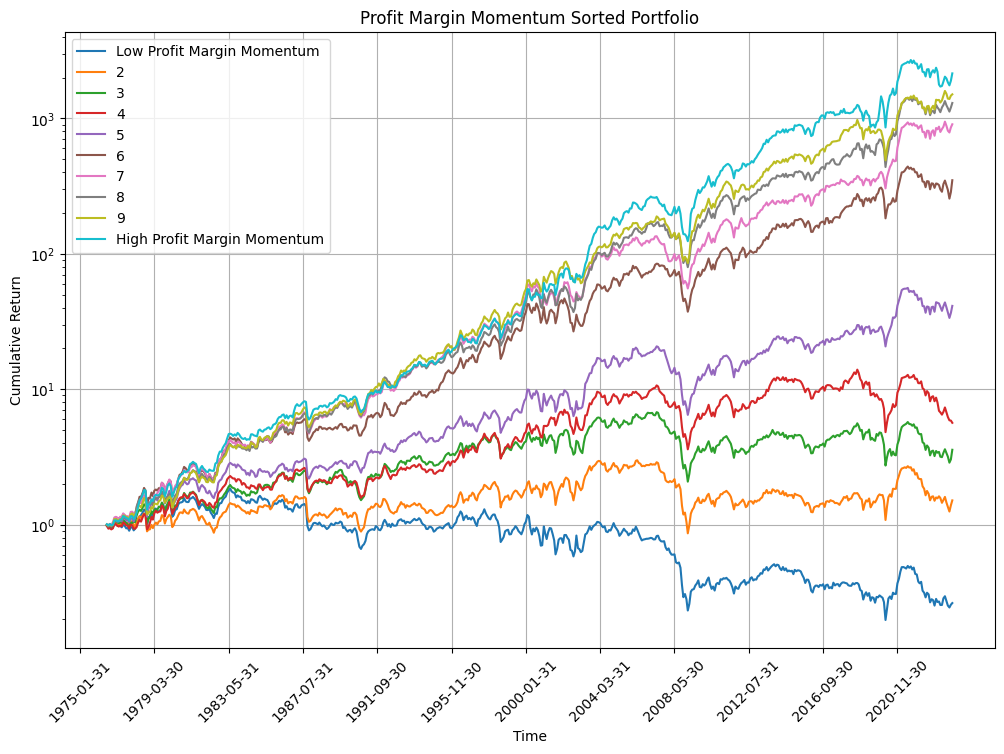

In [19]:
cost = [0.002*2 if idx_Q[i] else 0 for i in range(len(idx_Q))]
plot_group_cum(pm_pct_portfolio - np.array(cost[:len(pm_pct_portfolio)]).reshape(-1, 1), "Profit Margin Momentum")

In [20]:
#create cost vector that charge every quarter
cost = [0.002*2 if idx_Q[i] else 0 for i in range(len(idx_Q))]

In [21]:
pm_ls = ls(pm_pct_portfolio, -1, 0) - cost[:len(pm_pct_portfolio)]
mm_ls = ls(mom_portfolio, -1, 0) - 0.002*2
pm_val_ls = ls(pm_portfolio, -1, 0) - cost[:len(pm_portfolio)]
mm_ls = mm_ls[mm_ls.index >= pm_ls.index[0]]
comparison_df = pd.concat(
    [get_aggregated_annual_metrics(pm_ls), get_aggregated_annual_metrics(mm_ls), get_aggregated_annual_metrics(pm_val_ls)], axis=1
)
comparison_df.columns = ["PM Momentum", "Price Momentum", "PM"]
print(comparison_df.to_latex())

\begin{tabular}{llll}
\toprule
 & PM Momentum & Price Momentum & PM \\
\midrule
Mean & 17.34% & 9.58% & 14.06% \\
Std & 12.55% & 29.27% & 22.48% \\
SR & 1.38 & 0.33 & 0.63 \\
MDD & 25.70% & 99.07% & 71.53% \\
\bottomrule
\end{tabular}



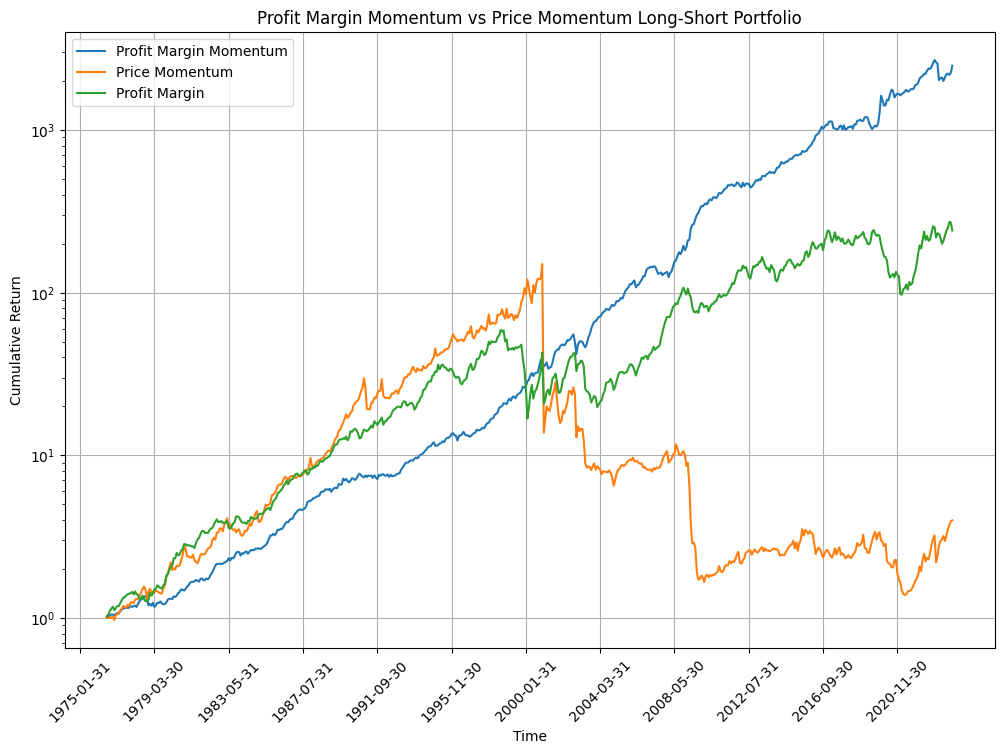

In [22]:
common_idx = pm_ls.dropna().index.intersection(mm_ls.dropna().index).intersection(pm_val_ls.dropna().index)
pm_ls_cumprod = (1+pm_ls[common_idx]).cumprod()
mm_ls_cumprod = (1+mm_ls[common_idx]).cumprod()
pm_val_ls_cumprod = (1+pm_val_ls[common_idx].dropna()).cumprod()
plt.figure(figsize=(12,8))
plt.plot(pm_ls_cumprod, label='Profit Margin Momentum')
plt.plot(mm_ls_cumprod, label='Price Momentum')
plt.plot(pm_val_ls_cumprod, label='Profit Margin')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.xticks(pm_ls.index[::50], rotation=45)
plt.yscale('log')
plt.title(f"Profit Margin Momentum vs Price Momentum Long-Short Portfolio")
plt.grid()
plt.legend()
plt.show()

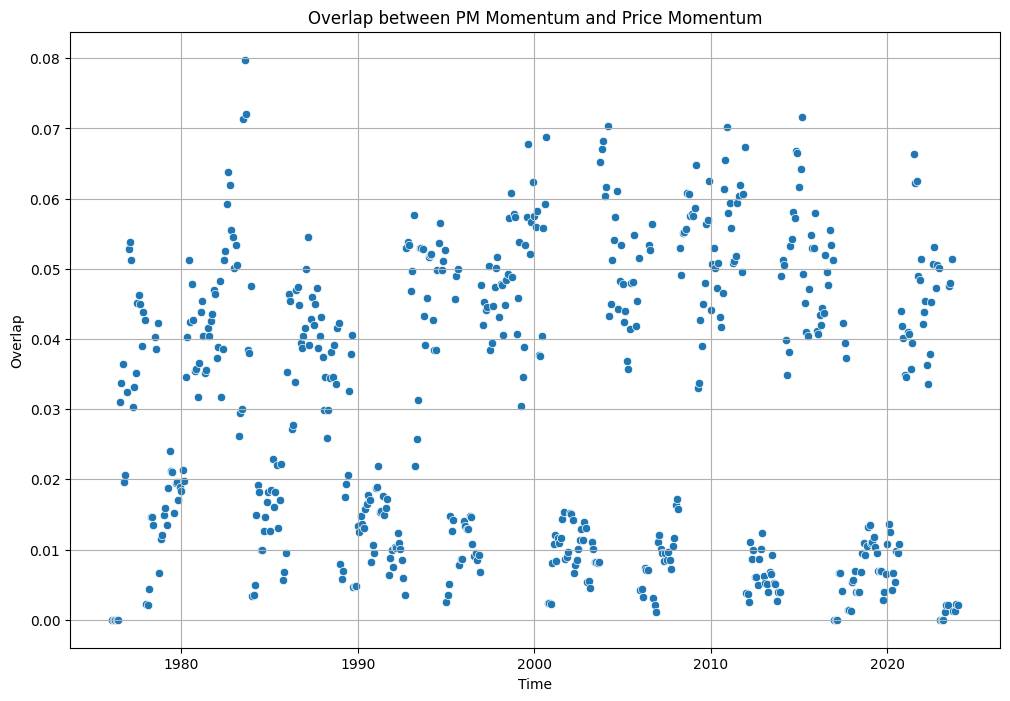

0.03079330559451294


In [23]:
l1 = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
l2 = get_sorted_index(df_mom * dfs['idx_vol_threshold'],holding_period=3)

overlap_long = count_overlap(l1[0], l2[0])
overlap_short = count_overlap(l1[-1], l2[-1])
overlap = (overlap_long + overlap_short) / 2
plt.figure(figsize=(12, 8))
sns.scatterplot(overlap)
plt.xlabel('Time')
plt.ylabel('Overlap')
plt.title('Overlap between PM Momentum and Price Momentum')
plt.grid()
plt.show()
print(overlap.mean())

In [24]:
rf = factor3['RF']
rf = rf[rf.index >= pm_ls.index[0]]
rf = rf[rf.index <= pm_ls.index[-1]]
rf['_'] = rf.iloc[-1]
rf.index = pm_ls.index

In [25]:
y = truncate(pm_ls - rf)
dic = {'MKT': truncate(factor3['Mkt-RF']),
       'SMB': truncate(factor3['SMB']),
       'HML': truncate(factor3['HML']),
       'MOM': truncate(mm_ls)
       
}
model = lin_reg(y, dic)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     3.420
Date:                Tue, 10 Dec 2024   Prob (F-statistic):            0.00891
Time:                        23:15:30   Log-Likelihood:                 1085.0
No. Observations:                 570   AIC:                            -2160.
Df Residuals:                     565   BIC:                            -2138.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0105      0.002      6.749      0.000       0.007       0.014
MKT           -0.0181      0.036     -0.508      0.612      -0.088       0.052
SMB            0.0413      0.054      0.772      0.441      -0.064       0.147
HML            0.1761      0.051      3.441      0.001       0.076       0.277
MOM            0.0173      0.018      0.950      0.342      -0.018       0.053
==============================================================================
Omnibus:                      115.441   Durbin-Watson:                   1.824
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1666.562
Skew:                           0.409   Prob(JB):                         0.00
Kurtosis:                      11.337   Cond. No.                         37.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
print(get_formatted_spanning_test_results(model.fit()))

\begin{tabular}{lccccc}
\toprule
 & const & MKT & SMB & HML & MOM \\
\midrule
Coefficient & 0.011 & -0.018 & 0.041 & 0.176 & 0.017 \\
t-statistic & (6.75) & (-0.51) & (0.77) & (3.44) & (0.95) \\
\bottomrule
\end{tabular}


In [27]:
y = ls(mom_portfolio, -1, 0) - rf

dic = {'MKT': truncate(factor3['Mkt-RF']),
       'SMB': truncate(factor3['SMB']),
       'HML': truncate(factor3['HML']),
       'PMM': truncate(ls(pm_pct_portfolio, -1, 0))
       
}
model = lin_reg(y, dic)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     5.512
Date:                Tue, 10 Dec 2024   Prob (F-statistic):           0.000234
Time:                        23:15:30   Log-Likelihood:                 611.04
No. Observations:                 570   AIC:                            -1212.
Df Residuals:                     565   BIC:                            -1190.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0093      0.004      2.414      0.016       0.002       0.017
MKT           -0.2500      0.081     -3.079      0.002      -0.409      -0.091
SMB           -0.2475      0.123     -2.018      0.044      -0.488      -0.007
HML           -0.3376      0.118     -2.859      0.004      -0.569      -0.106
PMM            0.1399      0.098      1.421      0.156      -0.053       0.333
==============================================================================
Omnibus:                      433.122   Durbin-Watson:                   2.113
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            17369.457
Skew:                          -2.888   Prob(JB):                         0.00
Kurtosis:                      29.419   Cond. No.                         37.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
print(get_formatted_spanning_test_results(model.fit()))

\begin{tabular}{lccccc}
\toprule
 & const & MKT & SMB & HML & PMM \\
\midrule
Coefficient & 0.009 & -0.250 & -0.248 & -0.338 & 0.140 \\
t-statistic & (2.41) & (-3.08) & (-2.02) & (-2.86) & (1.42) \\
\bottomrule
\end{tabular}


In [29]:
matrics(truncate(ls(pm_pct_portfolio, -1, 0)))

Annualized return for factor is 19.12%
t-value for factor is 1.5381


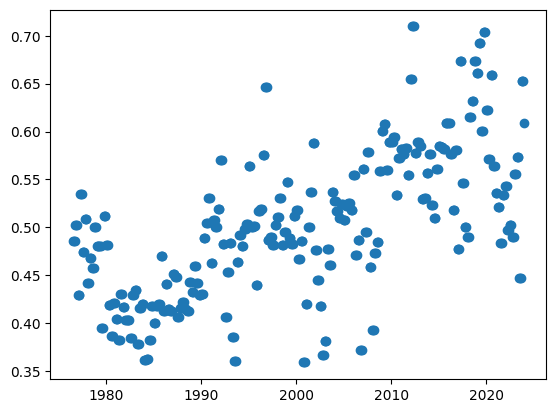

0.5010296392274022


In [30]:
l1 = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
l2 = get_sorted_index(df_eps_pct * dfs['idx_vol_threshold'],holding_period=3)

overlap_long = count_overlap(l1[0], l2[0])
overlap_short = count_overlap(l1[-1], l2[-1])
overlap = (overlap_long + overlap_short) / 2
plt.scatter(overlap.index, overlap.values)
plt.show()
print(overlap.mean())

# Double Sort Protfolios based on Price Momentum, EPS, and Profit Margin

In [31]:
pm_index = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.25,0.75])
        )

eps_index = get_sorted_index(
        df_eps_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.2,0.8])
        )

df_mom_Q = df_mom.copy()
df_mom_Q[~idx_Q] = np.nan
mom_index = get_sorted_index(
        df_mom_Q * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.3,0.7])
        )

In [32]:
condition_pm_eps = []
for i in range(len(eps_index)):
    condition_pm_eps.append(eps_index[i] * pm_index[i])
condition_mom_eps = []
for i in range(len(eps_index)):
    condition_mom_eps.append(eps_index[i] * mom_index[i])
condition_pm_mom = []
for i in range(len(pm_index)):
    condition_pm_mom.append(pm_index[i] * mom_index[2])
    
condition_pm_mom_low = []
for i in range(len(pm_index)):
    condition_pm_mom_low.append(pm_index[i] * mom_index[0])

In [33]:
eps_benchmark_index = get_sorted_index(
        df_eps_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.1,0.9])
        )

pm_benchmark_index = get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3, quantiles = np.array([0.1,0.9])
        )

mom_benchmark_index = get_sorted_index(
        df_mom * dfs['idx_vol_threshold'],
        holding_period=1, quantiles = np.array([0.1,0.9])
        )

eps_benchmark_portfolio = get_sorted_portfolio(
    dfs['ret'], eps_benchmark_index
)

pm_benchmark_portfolio = get_sorted_portfolio(
    dfs['ret'], pm_benchmark_index
)

mom_benchmark_portfolio = get_sorted_portfolio(
    dfs['ret'], mom_benchmark_index
)

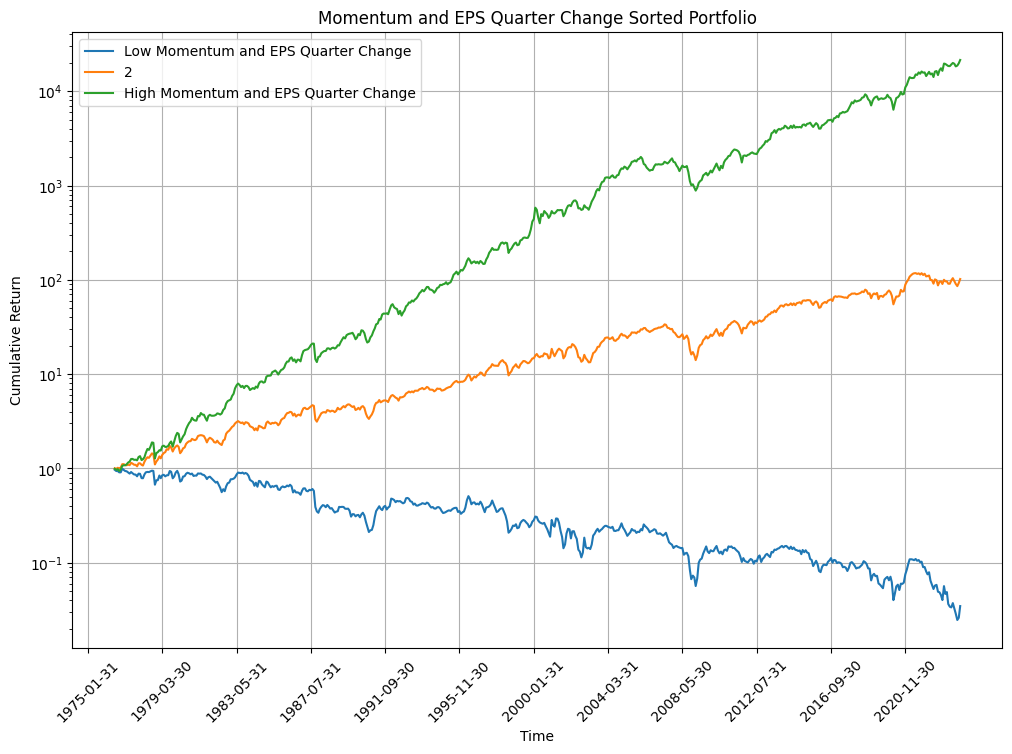

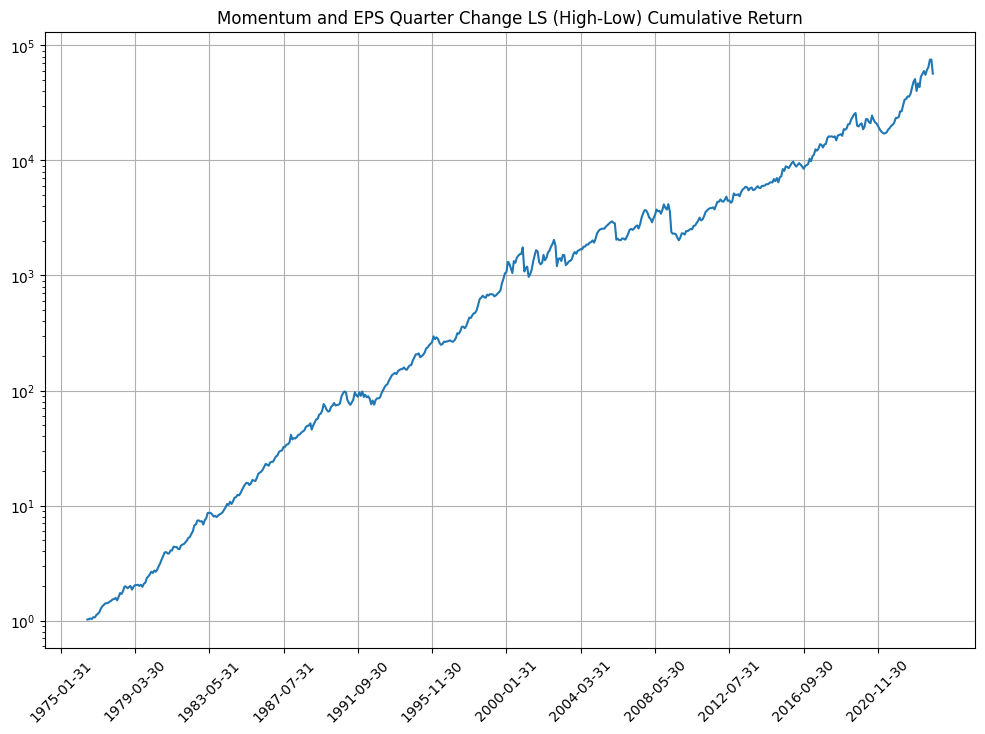

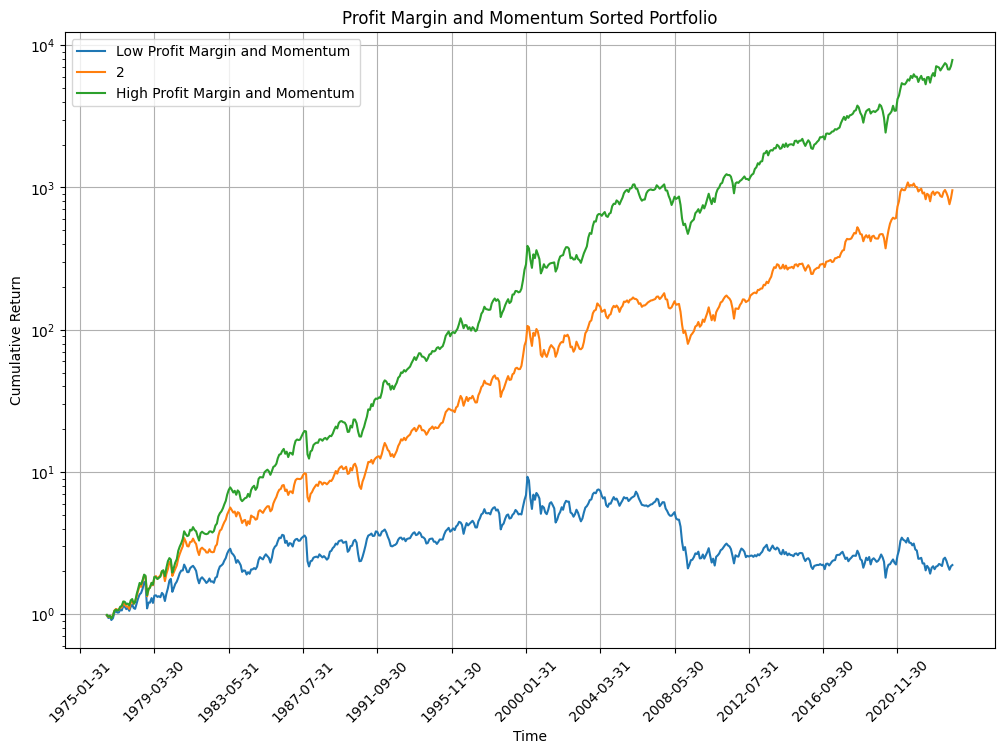

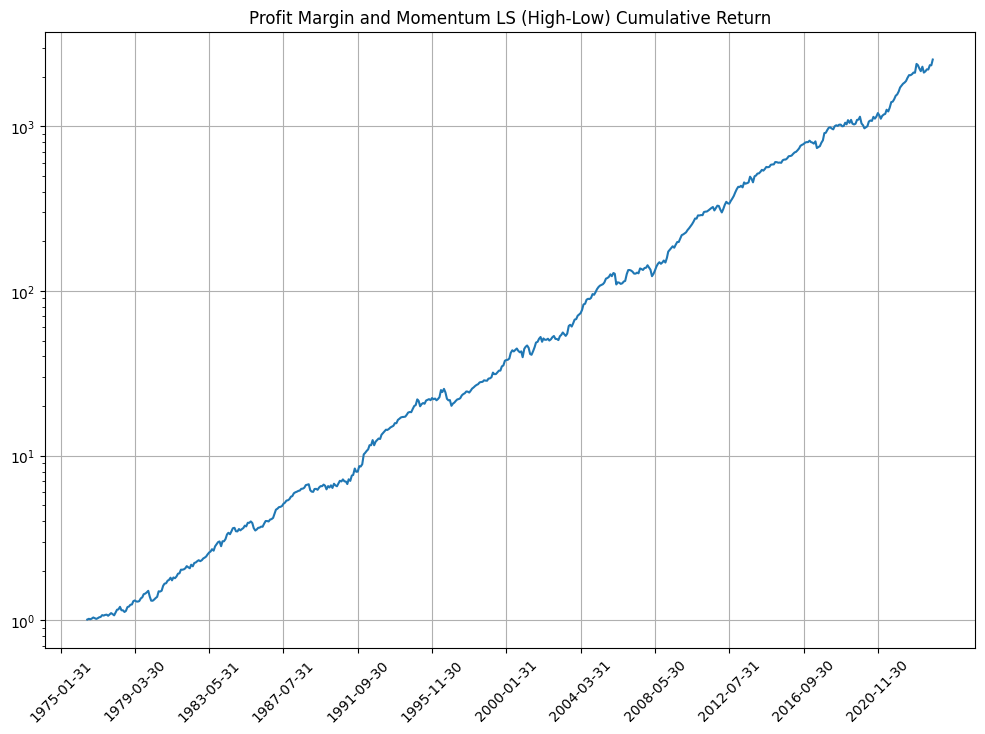

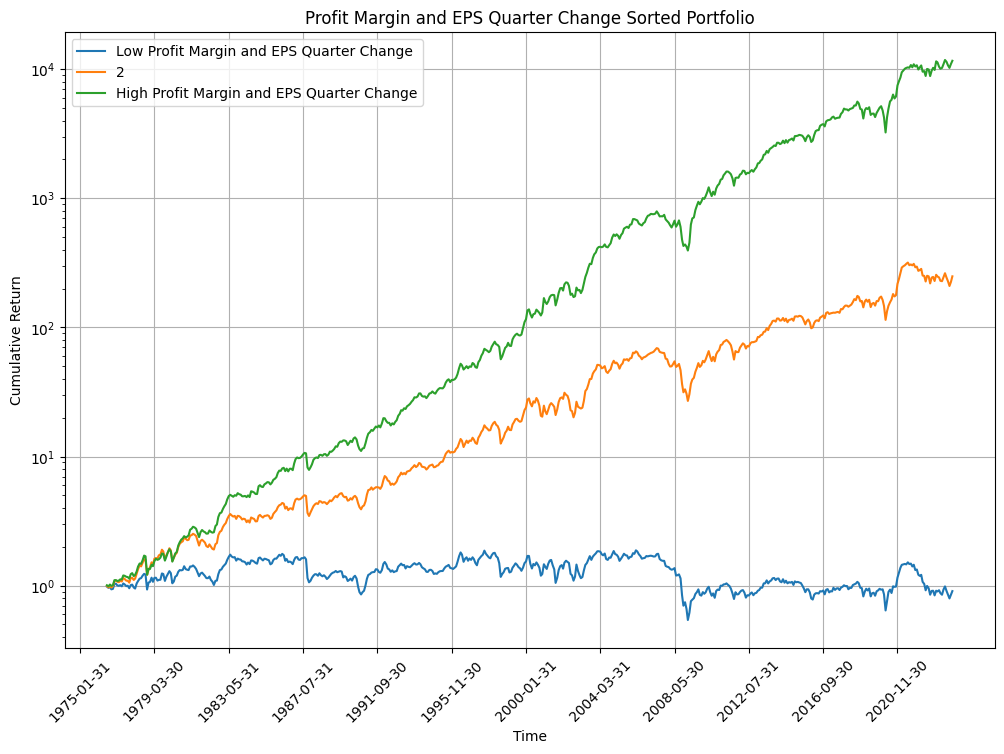

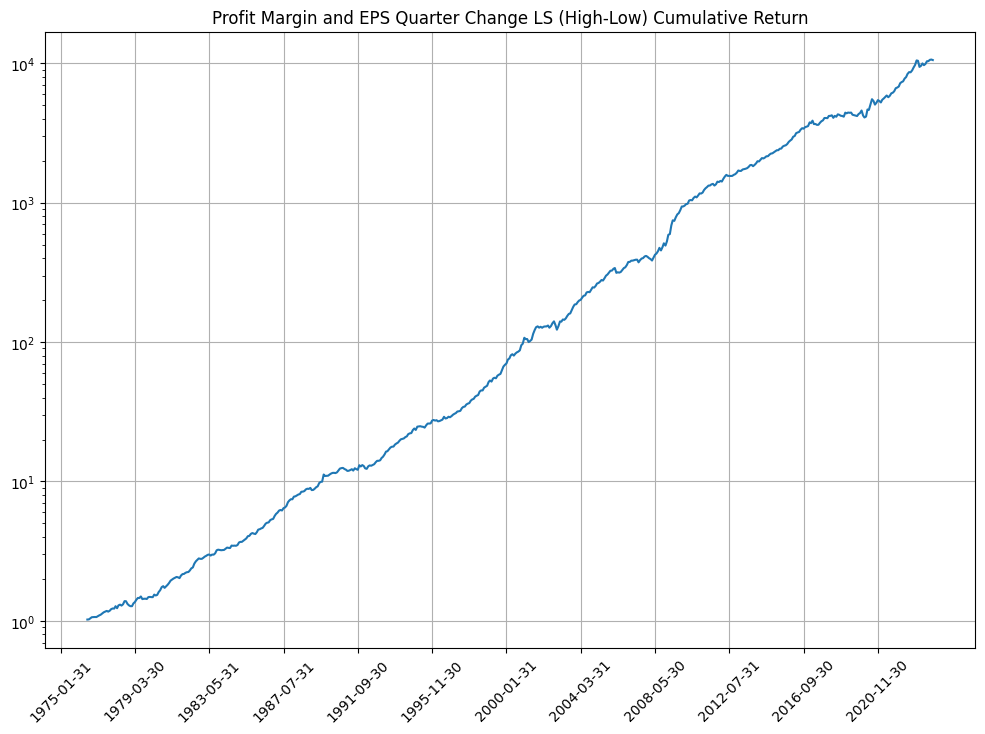

In [34]:
condition_mom_eps_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_mom_eps
)
plot_group_cum(condition_mom_eps_portfolio, "Momentum and EPS Quarter Change")
plot_solo_cum(ls(condition_mom_eps_portfolio, -1, 0),
              "Momentum and EPS Quarter Change LS (High-Low) Cumulative Return")

condition_pm_mom_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_pm_mom
)
plot_group_cum(condition_pm_mom_portfolio, "Profit Margin and Momentum")
plot_solo_cum(ls(condition_pm_mom_portfolio, -1, 0),
              "Profit Margin and Momentum LS (High-Low) Cumulative Return")

condition_pm_eps_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_pm_eps
)
plot_group_cum(condition_pm_eps_portfolio, "Profit Margin and EPS Quarter Change")
plot_solo_cum(ls(condition_pm_eps_portfolio, -1, 0),
              "Profit Margin and EPS Quarter Change LS (High-Low) Cumulative Return")

condition_pm_mom_low_portfolio = get_sorted_portfolio(
    dfs['ret'], condition_pm_mom_low
)

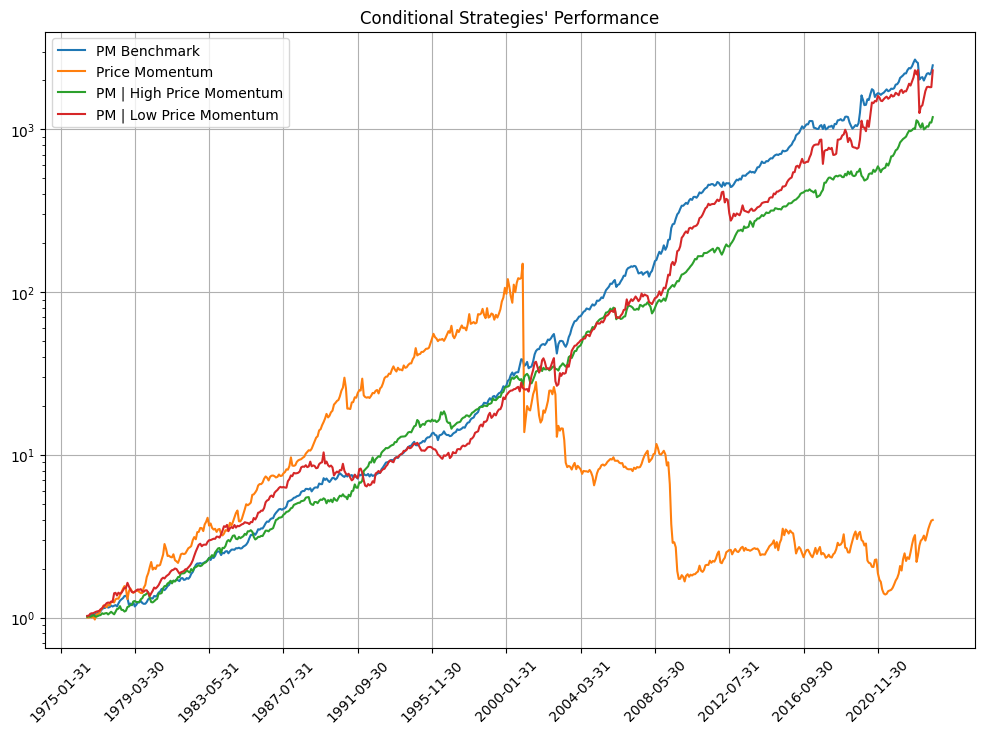

\begin{tabular}{llll}
\toprule
 & PM Benchmark & High Price PM. & Low Price PM. \\
\midrule
Mean & 17.34% & 15.68% & 18.43% \\
Std & 12.55% & 11.72% & 19.60% \\
SR & 1.38 & 1.34 & 0.94 \\
MDD & 25.70% & 21.79% & 45.56% \\
\bottomrule
\end{tabular}



In [35]:
pm_bmk = (ls(pm_benchmark_portfolio, -1,0)- cost[:len(pm_benchmark_portfolio)]).dropna()
mom_bmk = (ls(mom_benchmark_portfolio, -1,0)- 0.004).dropna()
pm_high_mom = (ls(condition_pm_mom_portfolio, -1,0)- cost[:len(condition_pm_mom_portfolio)]).dropna()
pm_low_mom = (ls(condition_pm_mom_low_portfolio, -1,0)- cost[:len(condition_pm_mom_low_portfolio)]).dropna()
common_idx = pm_bmk.index.intersection(mom_bmk.index).intersection(pm_high_mom.index).intersection(pm_low_mom.index)
pm_bmk_cumprod = (1+pm_bmk[common_idx]).cumprod()
mom_bmk_cumprod = (1+mom_bmk[common_idx]).cumprod()
pm_high_mom_cumprod = (1+pm_high_mom[common_idx]).cumprod()
pm_low_mom_cumprod = (1+pm_low_mom[common_idx]).cumprod() 
plt.figure(figsize=(12,8))
plt.plot(pm_bmk_cumprod, label='PM Benchmark')
plt.plot(mom_bmk_cumprod, label='Price Momentum')
plt.plot(pm_high_mom_cumprod, label='PM | High Price Momentum')
plt.plot(pm_low_mom_cumprod, label='PM | Low Price Momentum')
plt.xticks(ls(eps_pct_portfolio, -1, 0).index[::50], rotation=45)
plt.legend()
plt.yscale('log')
plt.title('Conditional Strategies\' Performance')
plt.grid()
plt.show()

comparison_df = pd.concat(
    [
        get_aggregated_annual_metrics(pm_bmk),
        get_aggregated_annual_metrics(pm_high_mom),
        get_aggregated_annual_metrics(pm_low_mom)
    ]
    , axis=1
)
comparison_df.columns = ["PM Benchmark", "High Price PM.", "Low Price PM."]
print(comparison_df.to_latex())

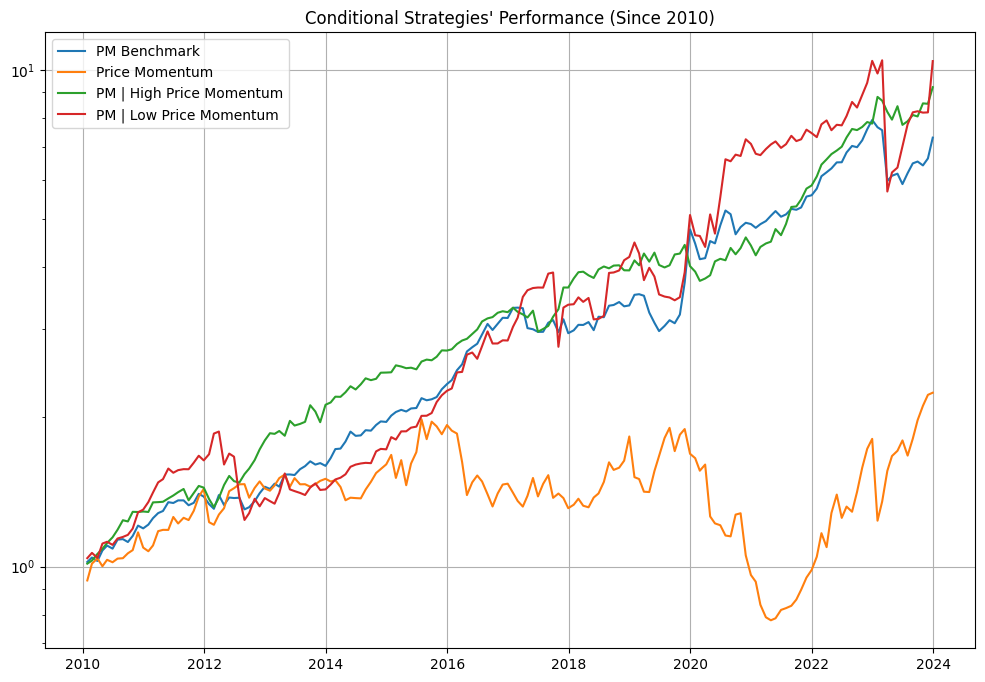

\begin{tabular}{llll}
\toprule
 & PM Benchmark & High Price PM. & Low Price PM. \\
\midrule
Mean & 15.39% & 16.65% & 20.59% \\
Std & 15.03% & 11.73% & 26.25% \\
SR & 1.02 & 1.42 & 0.78 \\
MDD & 25.70% & 15.36% & 45.56% \\
\bottomrule
\end{tabular}



In [36]:
cutoff_date = '2010-1-01'
cutlen = len(pm_benchmark_portfolio[pm_benchmark_portfolio.index >= cutoff_date])
pm_bmk_cumprod_cut = (1+pm_bmk[pm_bmk.index >= cutoff_date]).cumprod()
mom_bmk_cumprod_cut = (1+mom_bmk[mom_bmk.index >= cutoff_date]).cumprod()
pm_high_mom_cumprod_cut = (1+pm_high_mom[pm_high_mom.index >= cutoff_date]).cumprod()
pm_low_mom_cumprod_cut = (1+pm_low_mom[pm_low_mom.index >= cutoff_date]).cumprod()
plt.figure(figsize=(12,8))
plt.plot(pm_bmk_cumprod_cut, label='PM Benchmark')
plt.plot(mom_bmk_cumprod_cut, label='Price Momentum')
plt.plot(pm_high_mom_cumprod_cut, label='PM | High Price Momentum')
plt.plot(pm_low_mom_cumprod_cut, label='PM | Low Price Momentum')
plt.legend()
plt.yscale('log')
plt.title('Conditional Strategies\' Performance (Since 2010)')
plt.grid()
plt.show()

comparison_df = pd.concat(
    [
        get_aggregated_annual_metrics(pm_bmk[pm_bmk.index >= cutoff_date]),
        get_aggregated_annual_metrics(pm_high_mom[pm_high_mom.index >= cutoff_date]),
        get_aggregated_annual_metrics(pm_low_mom[pm_low_mom.index >= cutoff_date]),
    ]
    , axis=1
)
comparison_df.columns = ["PM Benchmark", "High Price PM.", "Low Price PM."]
print(comparison_df.to_latex())